# 04 · Modelo Preditivo de NPS

> **Desafio Opcional — Requisito 4 do Tech Challenge**

**Objetivo:** Construir e comparar modelos capazes de **prever o NPS antes da aplicação da pesquisa**, utilizando apenas dados operacionais disponíveis durante ou logo após a jornada de compra.

---

## Estratégia Adotada

O enunciado sugere duas abordagens possíveis. Em vez de escolher apenas uma, este notebook testa **as duas**, para comparar qual delas resolve melhor o problema de negócio:

### Abordagem A — Regressão
Estima a nota de NPS em escala contínua (0 a 10). Útil quando a empresa quer um **valor numérico exato** para priorizar ações (ex.: ordenar clientes do mais crítico ao menos crítico).

**Modelos testados:** Regressão Linear · Random Forest Regressor · Gradient Boosting Regressor

### Abordagem B — Classificação
Categoriza o cliente em **Detrator / Neutro / Promotor**. Útil quando a ação de negócio depende do *grupo* do cliente, não da nota exata (ex.: acionar equipe de retenção apenas para Detratores).

**Modelos testados:** Decision Tree · Random Forest · Gradient Boosting · Logistic Regression · SVM

---

### Por que comparar tantos modelos?

Não existe um modelo universalmente melhor — cada um tem vieses e pontos fortes diferentes:

| Modelo | Característica |
|---|---|
| Regressão Linear / Logística | Simples, interpretável, assume relações lineares |
| Decision Tree | Interpretável, captura não-linearidades, propenso a overfitting |
| Random Forest | Combina várias árvores, reduz overfitting, robusto |
| Gradient Boosting | Aprende com os erros sequencialmente, geralmente mais preciso |
| SVM | Bom em fronteiras de decisão complexas, mas custoso em bases grandes |

Testar todos permite **escolher com evidência**, não por suposição.

---


In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from src.utils import load_raw, add_nps_category, remove_leakage_cols, set_style, save_fig, PALETTE

# Pré-processamento
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Modelos de Regressão
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Modelos de Classificação
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Métricas de Regressão
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Métricas de Classificação
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, accuracy_score
)

set_style()
print('Ambiente pronto.')

Ambiente pronto.


## 1. Carregamento e Preparação Base dos Dados

Esta etapa é comum às duas abordagens: carrega os dados, remove colunas com *data leakage*, faz encoding de categóricas e cria as features de engenharia.

In [2]:
df = load_raw()
df = add_nps_category(df)

# ── Remoção de Data Leakage ──────────────────────────────────────────────────
# csat_internal_score e repeat_purchase_30d só existem DEPOIS do evento que
# queremos prever, então não podem entrar como feature.
df_features = remove_leakage_cols(df)
df_features = df_features.drop(columns=['customer_id', 'order_id', 'nps_category'], errors='ignore')

# ── Encoding de variáveis categóricas ───────────────────────────────────────
df_features = pd.get_dummies(df_features, columns=['customer_region'], drop_first=False)

# ── Feature Engineering ──────────────────────────────────────────────────────
df_features['discount_ratio']   = df_features['discount_value'] / (df_features['order_value'] + 1e-9)
df_features['has_delay']        = (df_features['delivery_delay_days'] > 0).astype(int)
df_features['high_contact']     = (df_features['customer_service_contacts'] >= 3).astype(int)
df_features['freight_per_item'] = df_features['freight_value'] / (df_features['items_quantity'] + 1e-9)

# X é igual para as duas abordagens — só o y (target) muda
X = df_features.copy()

print('Features utilizadas:', X.shape[1])
print(X.columns.tolist())

[load_raw] 2,500 linhas × 19 colunas carregadas de 'desafio_nps_fase_1.csv'
[remove_leakage_cols] Removidas: ['nps_score', 'csat_internal_score', 'repeat_purchase_30d']
Features utilizadas: 22
['customer_age', 'customer_tenure_months', 'order_value', 'items_quantity', 'discount_value', 'payment_installments', 'delivery_time_days', 'delivery_delay_days', 'freight_value', 'delivery_attempts', 'customer_service_contacts', 'resolution_time_days', 'complaints_count', 'customer_region_Centro-Oeste', 'customer_region_Nordeste', 'customer_region_Norte', 'customer_region_Sudeste', 'customer_region_Sul', 'discount_ratio', 'has_delay', 'high_contact', 'freight_per_item']


---
# PARTE A — ABORDAGEM POR REGRESSÃO

**Target:** `nps_score` (variável contínua, 0 a 10)

**Métricas usadas:**
- **MAE** (Erro Absoluto Médio) — em média, quantos pontos o modelo erra na nota
- **RMSE** (Raiz do Erro Quadrático Médio) — penaliza mais erros grandes
- **R²** (Coeficiente de Determinação) — quanto da variação do NPS o modelo consegue explicar (0 a 1, quanto maior melhor)

In [3]:
# Target de regressão: a nota NPS contínua
y_reg = df['nps_score'].values

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg,
    test_size=0.20,
    random_state=42
)

print(f'Treino: {X_train_r.shape[0]:,} amostras')
print(f'Teste:  {X_test_r.shape[0]:,} amostras')

Treino: 2,000 amostras
Teste:  500 amostras


In [4]:
# Regressão Linear é sensível à escala das variáveis, então padronizamos os dados.
# Modelos baseados em árvore (RF, GB) não precisam disso, mas não há problema em usar
# o mesmo conjunto padronizado para todos — simplifica o pipeline.
scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled = scaler_r.transform(X_test_r)

modelos_regressao = {
    'Regressão Linear': LinearRegression(),
    'Random Forest Regressor': RandomForestRegressor(
        n_estimators=200, max_depth=10, random_state=42, n_jobs=-1
    ),
    'Gradient Boosting Regressor': GradientBoostingRegressor(
        n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42
    ),
}

resultados_regressao = []

for nome, modelo in modelos_regressao.items():
    # Regressão Linear usa dados padronizados; os demais usam dados originais
    if nome == 'Regressão Linear':
        modelo.fit(X_train_r_scaled, y_train_r)
        y_pred = modelo.predict(X_test_r_scaled)
    else:
        modelo.fit(X_train_r, y_train_r)
        y_pred = modelo.predict(X_test_r)

    mae = mean_absolute_error(y_test_r, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_r, y_pred))
    r2 = r2_score(y_test_r, y_pred)

    resultados_regressao.append({
        'Modelo': nome, 'MAE': round(mae, 3), 'RMSE': round(rmse, 3), 'R²': round(r2, 3)
    })
    print(f'{nome:30s} | MAE: {mae:.3f} | RMSE: {rmse:.3f} | R²: {r2:.3f}')

df_resultados_reg = pd.DataFrame(resultados_regressao).sort_values('R²', ascending=False)
print('\n--- Ranking por R² ---')
print(df_resultados_reg.to_string(index=False))

Regressão Linear               | MAE: 1.336 | RMSE: 1.688 | R²: 0.549


Random Forest Regressor        | MAE: 1.398 | RMSE: 1.746 | R²: 0.518


Gradient Boosting Regressor    | MAE: 1.356 | RMSE: 1.700 | R²: 0.543

--- Ranking por R² ---
                     Modelo   MAE  RMSE    R²
           Regressão Linear 1.336 1.688 0.549
Gradient Boosting Regressor 1.356 1.700 0.543
    Random Forest Regressor 1.398 1.746 0.518


[save_fig] Salvo em '/home/claude/nps-ecommerce/reports/figures/07_comparacao_modelos_regressao.png'


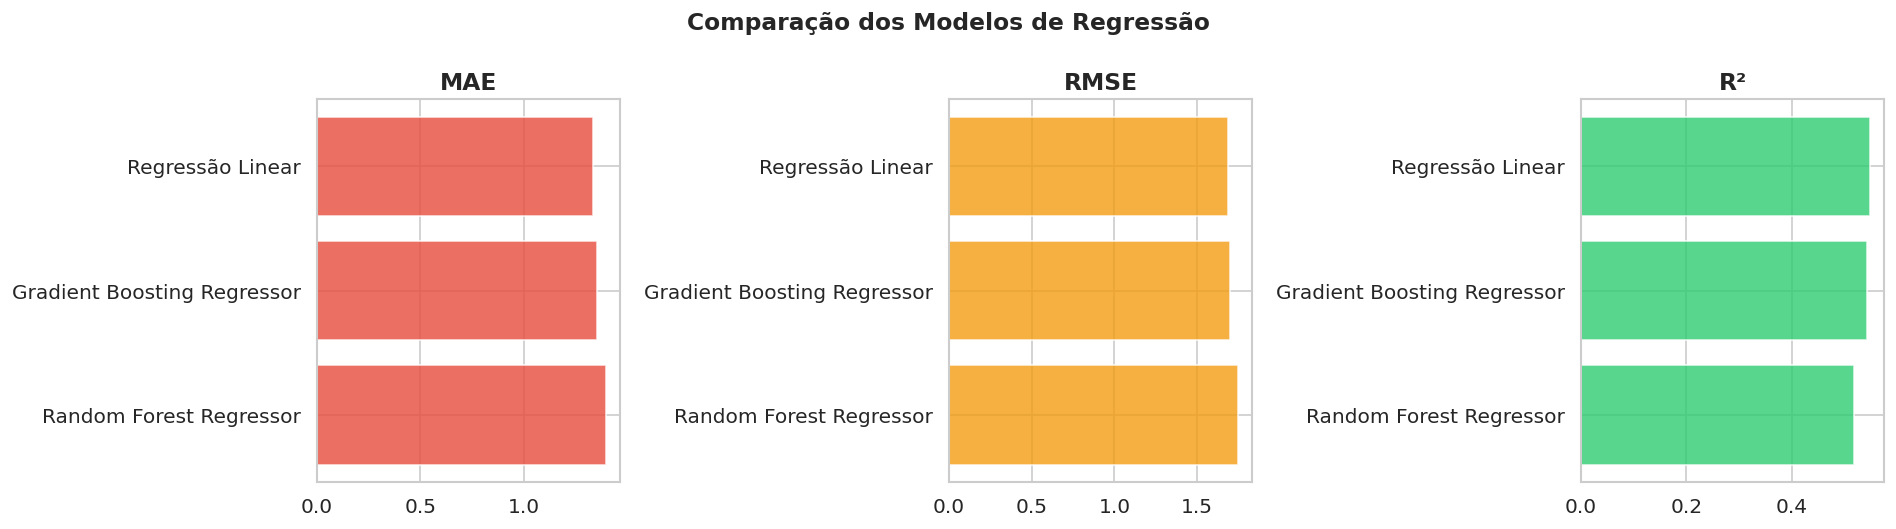

In [5]:
# Visualização comparativa dos modelos de regressão
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

metricas = ['MAE', 'RMSE', 'R²']
cores = ['#E74C3C', '#F39C12', '#2ECC71']

for ax, metrica, cor in zip(axes, metricas, cores):
    dados_plot = df_resultados_reg.sort_values(metrica, ascending=(metrica != 'R²'))
    ax.barh(dados_plot['Modelo'], dados_plot[metrica], color=cor, alpha=0.8)
    ax.set_title(metrica)
    ax.invert_yaxis()

fig.suptitle('Comparação dos Modelos de Regressão', fontsize=14, fontweight='bold')
save_fig(fig, '07_comparacao_modelos_regressao.png')
plt.show()

### Interpretação dos resultados (Regressão)

- **MAE** indica, em média, quantos pontos de NPS o modelo erra para cada cliente. Um MAE de 1.0, por exemplo, significa que a previsão erra em média 1 ponto na escala de 0 a 10.
- **R²** mostra o quanto da variação do NPS é explicada pelas variáveis operacionais. Valores mais próximos de 1 indicam melhor ajuste.
- Modelos baseados em árvore (Random Forest, Gradient Boosting) tendem a capturar melhor relações não-lineares, como o "ponto de ruptura" no atraso de entrega identificado na EDA — algo que a Regressão Linear, por ser um modelo linear, tem mais dificuldade de representar.

---
# PARTE B — ABORDAGEM POR CLASSIFICAÇÃO

**Target:** `nps_category` (Detrator / Neutro / Promotor)

**Métricas usadas:**
- **Acurácia** — percentual geral de acertos
- **F1-Score Macro** — média do F1 por classe, sem favorecer a classe majoritária (importante porque as classes são desbalanceadas)
- **Matriz de Confusão** — mostra onde o modelo confunde uma classe com outra

In [6]:
# Target de classificação: a categoria do cliente
y_class_raw = df['nps_category']

le = LabelEncoder()
y_class = le.fit_transform(y_class_raw)  # Detrator=0, Neutro=1, Promotor=2
class_names = le.classes_

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class   # mantém proporção das classes no treino e teste
)

print('Classes:', class_names)
print(f'Treino: {X_train_c.shape[0]:,} amostras')
print(f'Teste:  {X_test_c.shape[0]:,} amostras')
print('\nDistribuição no treino:')
print(pd.Series(le.inverse_transform(y_train_c)).value_counts())

Classes: ['Detrator' 'Neutro' 'Promotor']
Treino: 2,000 amostras
Teste:  500 amostras

Distribuição no treino:
Detrator    1481
Neutro       358
Promotor     161
Name: count, dtype: int64


In [7]:
# Logistic Regression e SVM são sensíveis à escala — usamos dados padronizados para eles.
# Decision Tree, Random Forest e Gradient Boosting não precisam de padronização.
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

modelos_classificacao = {
    'Decision Tree': DecisionTreeClassifier(
        max_depth=8, class_weight='balanced', random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42
    ),
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=42
    ),
    'SVM': SVC(
        kernel='rbf', class_weight='balanced', random_state=42, probability=False
    ),
}

# Modelos que precisam de dados padronizados
modelos_que_usam_scaling = {'Logistic Regression', 'SVM'}

resultados_classificacao = []
predicoes = {}

for nome, modelo in modelos_classificacao.items():
    if nome in modelos_que_usam_scaling:
        modelo.fit(X_train_c_scaled, y_train_c)
        y_pred = modelo.predict(X_test_c_scaled)
    else:
        modelo.fit(X_train_c, y_train_c)
        y_pred = modelo.predict(X_test_c)

    acc = accuracy_score(y_test_c, y_pred)
    f1_macro = f1_score(y_test_c, y_pred, average='macro')
    f1_weighted = f1_score(y_test_c, y_pred, average='weighted')

    resultados_classificacao.append({
        'Modelo': nome,
        'Acurácia': round(acc, 3),
        'F1-Macro': round(f1_macro, 3),
        'F1-Weighted': round(f1_weighted, 3)
    })
    predicoes[nome] = y_pred

    print(f'{nome:22s} | Acurácia: {acc:.3f} | F1-Macro: {f1_macro:.3f} | F1-Weighted: {f1_weighted:.3f}')

df_resultados_class = pd.DataFrame(resultados_classificacao).sort_values('F1-Macro', ascending=False)
print('\n--- Ranking por F1-Macro ---')
print(df_resultados_class.to_string(index=False))

Decision Tree          | Acurácia: 0.638 | F1-Macro: 0.475 | F1-Weighted: 0.677


Random Forest          | Acurácia: 0.760 | F1-Macro: 0.508 | F1-Weighted: 0.747


Gradient Boosting      | Acurácia: 0.780 | F1-Macro: 0.518 | F1-Weighted: 0.759
Logistic Regression    | Acurácia: 0.692 | F1-Macro: 0.540 | F1-Weighted: 0.724
SVM                    | Acurácia: 0.694 | F1-Macro: 0.533 | F1-Weighted: 0.721

--- Ranking por F1-Macro ---
             Modelo  Acurácia  F1-Macro  F1-Weighted
Logistic Regression     0.692     0.540        0.724
                SVM     0.694     0.533        0.721
  Gradient Boosting     0.780     0.518        0.759
      Random Forest     0.760     0.508        0.747
      Decision Tree     0.638     0.475        0.677


[save_fig] Salvo em '/home/claude/nps-ecommerce/reports/figures/08_comparacao_modelos_classificacao.png'


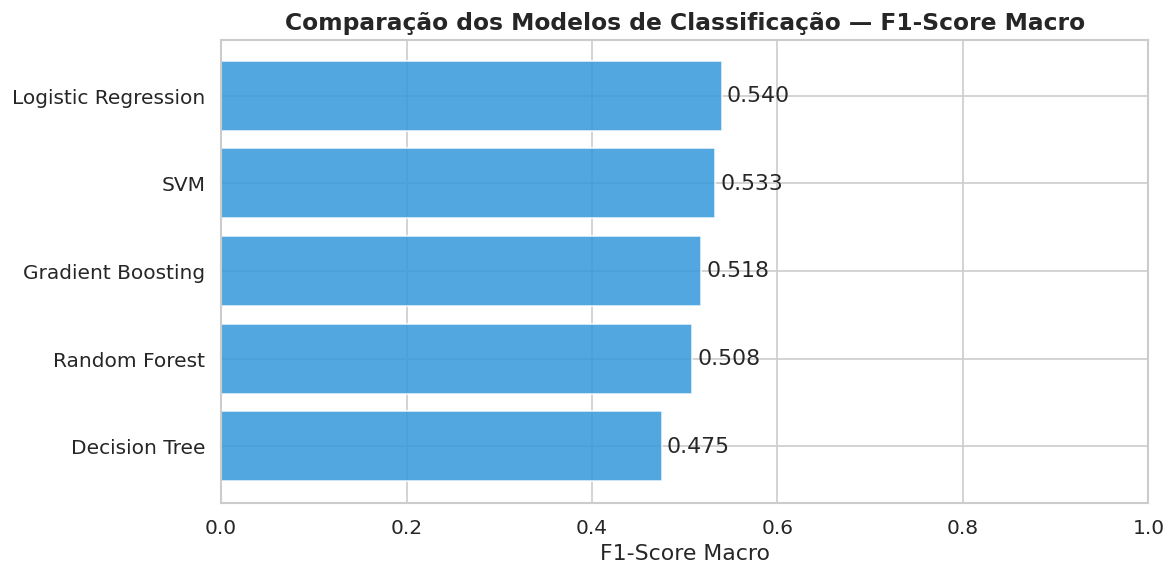

In [8]:
# Visualização comparativa dos modelos de classificação
fig, ax = plt.subplots(figsize=(10, 5))

dados_plot = df_resultados_class.sort_values('F1-Macro')
bars = ax.barh(dados_plot['Modelo'], dados_plot['F1-Macro'], color='#3498DB', alpha=0.85)
ax.set_xlabel('F1-Score Macro')
ax.set_title('Comparação dos Modelos de Classificação — F1-Score Macro')
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.set_xlim(0, 1)
save_fig(fig, '08_comparacao_modelos_classificacao.png')
plt.show()

Melhor modelo: Logistic Regression

              precision    recall  f1-score   support

    Detrator       0.94      0.76      0.84       370
      Neutro       0.33      0.46      0.38        90
    Promotor       0.30      0.57      0.39        40

    accuracy                           0.69       500
   macro avg       0.52      0.60      0.54       500
weighted avg       0.78      0.69      0.72       500



[save_fig] Salvo em '/home/claude/nps-ecommerce/reports/figures/09_confusion_matrix_logistic_regression.png'


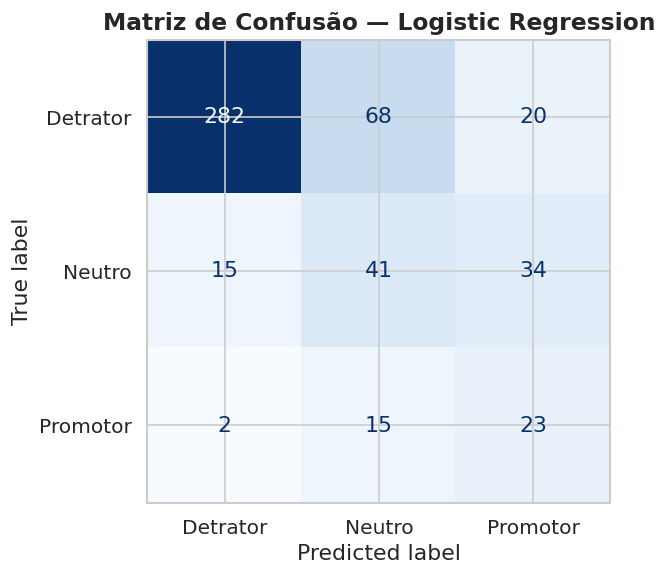

In [9]:
# Relatório detalhado e matriz de confusão do melhor modelo
melhor_nome = df_resultados_class.iloc[0]['Modelo']
melhor_pred = predicoes[melhor_nome]

print(f'Melhor modelo: {melhor_nome}\n')
print(classification_report(y_test_c, melhor_pred, target_names=class_names))

fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test_c, melhor_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Matriz de Confusão — {melhor_nome}')
save_fig(fig, f'09_confusion_matrix_{melhor_nome.lower().replace(" ", "_")}.png')
plt.show()

### Interpretação dos resultados (Classificação)

- **Acurácia** pode enganar em bases desbalanceadas — por isso priorizamos o **F1-Score Macro**, que trata todas as classes (Detrator, Neutro, Promotor) com o mesmo peso.
- A classe **Neutro** costuma ser a mais difícil de prever, pois fica na fronteira entre Detrator e Promotor — vale observar seu Recall na matriz de confusão.
- **SVM** e **Logistic Regression** dependem de padronização e tendem a funcionar melhor quando as relações são aproximadamente lineares; modelos de árvore costumam capturar melhor padrões como o ponto de ruptura do atraso de entrega.

---
## Comparação Final: Regressão vs Classificação — Qual abordagem usar?

| Critério | Regressão | Classificação |
|---|---|---|
| Saída do modelo | Nota estimada (ex.: 4.7) | Categoria (Detrator/Neutro/Promotor) |
| Quando usar | Priorizar clientes por grau de risco | Acionar fluxos de ação por grupo |
| Métrica chave | MAE / R² | F1-Score Macro |
| Vantagem | Granularidade — permite ranquear clientes | Simplicidade de ação — decisão binária/ternária |
| Limitação | Erro pode "borrar" a fronteira entre categorias | Perde a informação de quão extremo é o caso |

**Recomendação prática:** usar a **classificação** para alertas operacionais simples (ex.: "acionar atendimento"), e a **regressão** quando for necessário ranquear clientes por prioridade dentro de um mesmo grupo de risco.


## Salvando os Melhores Modelos

In [10]:
import joblib
from pathlib import Path

MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Melhor modelo de regressão (maior R²)
melhor_nome_reg = df_resultados_reg.iloc[0]['Modelo']
melhor_modelo_reg = modelos_regressao[melhor_nome_reg]

# Melhor modelo de classificação (maior F1-Macro)
melhor_nome_class = df_resultados_class.iloc[0]['Modelo']
melhor_modelo_class = modelos_classificacao[melhor_nome_class]

joblib.dump(melhor_modelo_reg, MODELS_DIR / 'nps_regressor.pkl')
joblib.dump(melhor_modelo_class, MODELS_DIR / 'nps_classifier.pkl')
joblib.dump(le, MODELS_DIR / 'label_encoder.pkl')
joblib.dump(scaler_c, MODELS_DIR / 'scaler.pkl')
joblib.dump(X.columns.tolist(), MODELS_DIR / 'feature_names.pkl')

print(f'Melhor regressor salvo:      {melhor_nome_reg} → models/nps_regressor.pkl')
print(f'Melhor classificador salvo:  {melhor_nome_class} → models/nps_classifier.pkl')

Melhor regressor salvo:      Regressão Linear → models/nps_regressor.pkl
Melhor classificador salvo:  Logistic Regression → models/nps_classifier.pkl


---
## Limitações e Cuidados

| Risco | Descrição |
|---|---|
| **Data Leakage** | `csat_internal_score` e `repeat_purchase_30d` foram excluídos — não estariam disponíveis em produção |
| **Drift temporal** | O modelo deve ser re-treinado periodicamente à medida que o comportamento do cliente muda |
| **Classe Neutro** | Clientes Neutros são os mais difíceis de classificar; monitorar seu Recall |
| **Causalidade** | Alta importância de uma feature não significa que agir nela causará mudança no NPS — correlação ≠ causalidade |
| **Generalização** | O modelo foi treinado com 2.500 registros; validar com dados mais recentes antes de produção |
| **SVM em produção** | SVM não escala bem para bases muito maiores que a atual — reavaliar se a base crescer significativamente |
